In [1]:
!pip install ucimlrepo

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

In [3]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

In [4]:
import zipfile

with zipfile.ZipFile('/content/sample_data/sms+spam+collection.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [5]:
import os

os.listdir('/content/')

['.config', 'sample_data', 'readme', 'SMSSpamCollection']

In [6]:
import pandas as pd

df = pd.read_csv(
    '/content/SMSSpamCollection',
    sep='\t',
    header=None,
    names=['label', 'message']
)

In [7]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
print(df.columns)
print(df.shape)
print(df["label"].value_counts())

Index(['label', 'message'], dtype='object')
(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


In [9]:
X = df["message"]
y = df["label"]

In [10]:
y = y.map({
    "ham": 0,
    "spam": 1
})

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [13]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Naive Bayes")
print("Accuracy :", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred))
print("Recall   :", recall_score(y_test, nb_pred))
print("F1 Score :", f1_score(y_test, nb_pred))

Naive Bayes
Accuracy : 0.9704035874439462
Precision: 1.0
Recall   : 0.7785234899328859
F1 Score : 0.8754716981132076


In [15]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

In [16]:
print("SVM")
print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall   :", recall_score(y_test, svm_pred))
print("F1 Score :", f1_score(y_test, svm_pred))

SVM
Accuracy : 0.9838565022421525
Precision: 0.9924812030075187
Recall   : 0.8859060402684564
F1 Score : 0.9361702127659575


In [17]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_tfidf, y_train)

dt_pred = dt_model.predict(X_test_tfidf)

In [18]:
print("Decision Tree")
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

Decision Tree
Accuracy : 0.9623318385650225
Precision: 0.8848920863309353
Recall   : 0.825503355704698
F1 Score : 0.8541666666666666


In [19]:
results = {
    "Model": [
        "Naive Bayes",
        "SVM",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, dt_pred)
    ],
    "Precision": [
        precision_score(y_test, nb_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, dt_pred)
    ],
    "Recall": [
        recall_score(y_test, nb_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, dt_pred)
    ],
    "F1 Score": [
        f1_score(y_test, nb_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, dt_pred)
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.970404,1.000000,0.778523,0.875472
1,SVM,0.983857,0.992481,0.885906,0.936170
2,Decision Tree,0.962332,0.884892,0.825503,0.854167


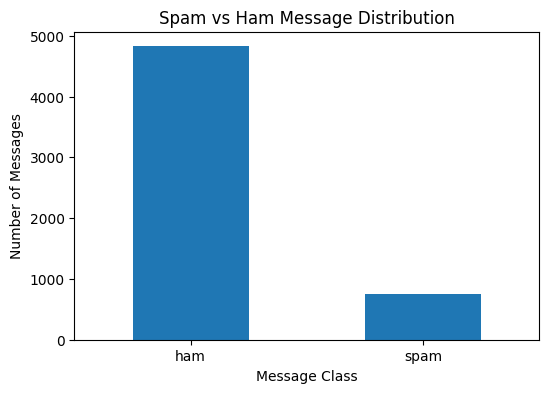

In [20]:
import matplotlib.pyplot as plt

class_counts = df["label"].value_counts()

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")

plt.title("Spam vs Ham Message Distribution")
plt.xlabel("Message Class")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)

plt.show()